In [2]:
import sys
from pathlib import Path

# make the project root importable when the notebook runs from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [3]:
import numpy as np
import pandas as pd


def implied_rate(calls: pd.DataFrame, puts: pd.DataFrame) -> float:
    """Estimate risk-free rate from call-put parity."""
    rates = []
    for exp, cg in calls.groupby("expiry"):
        m = cg.merge(puts[puts.expiry == exp], on="strike", suffixes=("_c", "_p"))
        if len(m) < 3:
            continue
        T = float(m["ttm_c"].iloc[0])
        slope, _ = np.polyfit(m["strike"], m["mid_c"] - m["mid_p"], 1)
        disc = -slope                                   # e^{-rT}
        if disc > 0:
            rates.append(-np.log(disc) / T)
    return float(np.median(rates))

In [ ]:
from src.data.data_loader import DataLoader

loader = DataLoader()
CHAIN_PATH = "../data/spx_option_chain.parquet"

# Re-pull a chain spread over a MATURITY LADDER (~1 week .. ~1 year) so Heston's
# term-structure params (a, v_mean) are identifiable. The old cache held only ~2 weeks
# of expiries, which left a/v_mean unidentified (the a=987 blow-up). Run once; comment
# the two lines below out to reuse the cached snapshot.
#chain = loader.load_option_chain(ticker="^SPX", n_maturities=8, min_days=7, max_days=400)
loader.save_parquet(chain, CHAIN_PATH)

chain = loader.load_parquet(CHAIN_PATH)
print("expiries:", sorted(chain.expiry.unique().tolist()))

expiries: ['2026-06-23', '2026-07-01', '2026-07-10', '2026-07-20', '2026-08-07', '2026-10-16', '2027-01-15', '2027-06-17']


In [5]:
# tradable two-sided quotes with real time-to-maturity
chain = chain[(chain.bid > 0) & (chain.ask > 0) & (chain.ttm > 0)].copy()
chain["mid"] = (chain.bid + chain.ask) / 2
s0 = float(chain.spot.iloc[0])

# risk-free rate from put-call parity (needs matched calls & puts) -- compute before any cut
r = implied_rate(chain[chain.type == "call"], chain[chain.type == "put"])

# Calibrate on OTM options (less noisy than deep-ITM): OTM calls (K >= s0) + OTM puts
# (K < s0). Convert the puts to call-equivalents via parity  C = P + s0 - K e^{-rT}
# (shift bid/ask/mid by the same constant) so everything lives in call-price space and
# the downstream call pricer / bid-ask diagnostics stay valid.
otm_c = chain[(chain.type == "call") & (chain.strike >= s0)].copy()
otm_p = chain[(chain.type == "put")  & (chain.strike <  s0)].copy()
shift = s0 - otm_p.strike * np.exp(-r * otm_p.ttm)
for col in ("bid", "ask", "mid"):
    otm_p[col] = otm_p[col] + shift

calls = pd.concat([otm_c, otm_p], ignore_index=True)

# keep liquid, near-the-money quotes
mny = calls.strike / s0
calls = calls[mny.between(0.80, 1.20) & ((calls.ask - calls.bid) < 0.05 * calls.mid)]
print(f"n_quotes={len(calls)}  maturities={calls.ttm.nunique()}  s0={s0:.1f}  r={r:.4f}")

n_quotes=1145  maturities=8  s0=7511.6  r=0.0573


In [6]:
# parallel arrays, all from the same filtered frame -> guaranteed index-aligned
k = calls.strike.to_numpy(float)
t = calls.ttm.to_numpy(float)
call = calls.mid.to_numpy(float)

In [7]:
### Cell for JAX CPU setup -- MUST run before any `import jax` (restart kernel if it already ran)

import os

os.environ["JAX_PLATFORMS"] = "cpu"          # no GPU driver in this WSL2 instance
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"  # 4 logical CPUs -> 4 NUTS chains run in parallel

import jax

jax.local_device_count()  # should print 4

4

In [8]:
from src.algorithms.heston.heston_analytics import HestonModel
from src.algorithms.heston.heston_config import (
    HestonCalibrationConfig,
    NUTSConfig,
    QuadConfig,
)
from src.algorithms.heston.heston_params import HestonParams

# sane SPX-like start (~20% vol, downward skew) -- not the earlier extreme v_0=0.5, rho=+0.5
initial_params = HestonParams(v_0=0.04, v_mean=0.04, a=2.0, eta=0.5, rho=-0.7)

# lighter sampler + quadrature so calibration finishes in minutes, not hours
cfg = HestonCalibrationConfig(
    nuts=NUTSConfig(num_warmup=400, num_samples=400, num_chains=4),
    quad=QuadConfig(n_quad=64),
)
model = HestonModel(initial_params, cfg)
model.optimize_params(k=k, s_0=s0, r=r, t=t, call=call)

/mnt/d/Projects/QuantFlow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Bad value of the params: Feller condition isnt satisfied.


In [9]:
print(model.params)

HestonParams(v_0=0.02301376046535026, v_mean=0.13534288873361652, a=0.6574533023522834, eta=1.0027356336831081, rho=-0.7010276120728997)


In [10]:
# check the differ
import numpy as np

bid = calls["bid"].to_numpy(float)
ask = calls["ask"].to_numpy(float)
mid = call

c_model = model.call(k, s0, r, t)

abs_err   = np.abs(c_model - mid)
within    = (c_model >= bid) & (c_model <= ask)
half_sprd = abs_err <= (ask - bid) / 2  

print(f"% inside bid-ask : {100*within.mean():.1f}%")
print(f"% within ½-spread: {100*half_sprd.mean():.1f}%")
print(f"RMSE (price)     : {np.sqrt(np.mean((c_model-mid)**2)):.3f}")
print(f"mean |err|/mid   : {100*np.mean(abs_err/mid):.2f}%")

iv_mkt   = model._implied_vol(mid, s0, k, r, t)
iv_model = model._implied_vol(c_model, s0, k, r, t)
m = np.isfinite(iv_mkt) & np.isfinite(iv_model)
print(f"RMSE (impl vol)  : {100*np.sqrt(np.mean((iv_model[m]-iv_mkt[m])**2)):.2f} vol pts")

% inside bid-ask : 5.2%
% within ½-spread: 5.2%
RMSE (price)     : 14.532
mean |err|/mid   : 4.16%
RMSE (impl vol)  : 1.69 vol pts


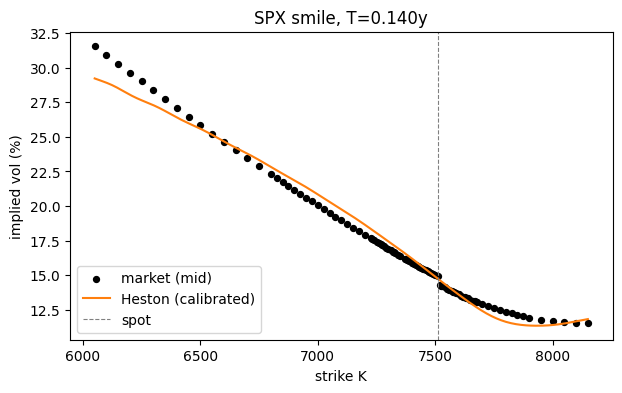

In [11]:
import matplotlib.pyplot as plt

T = float(np.median(t))                      # pick one maturity to draw
sel = np.isclose(t, T)                        # market quotes at that maturity

# dense strike grid for the smooth model curve (other strikes — allowed!)
k_dense = np.linspace(k[sel].min(), k[sel].max(), 200)
t_dense = np.full_like(k_dense, T)
iv_curve = model._implied_vol(model.call(k_dense, s0, r, t_dense),
                              s0, k_dense, r, t_dense)

iv_mkt_sel = model._implied_vol(mid[sel], s0, k[sel], r, T)

plt.figure(figsize=(7, 4))
plt.scatter(k[sel], 100*iv_mkt_sel, s=18, label="market (mid)", color="k")
plt.plot(k_dense, 100*iv_curve, label="Heston (calibrated)", color="C1")
plt.axvline(s0, ls="--", lw=0.8, color="gray", label="spot")
plt.xlabel("strike K"); plt.ylabel("implied vol (%)")
plt.title(f"SPX smile, T={T:.3f}y"); plt.legend(); plt.show()

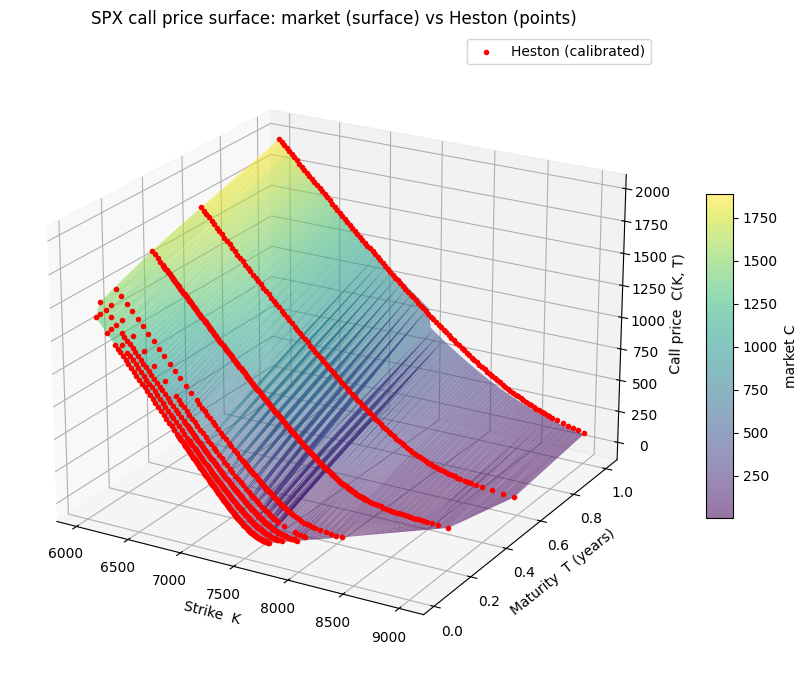

In [12]:
import numpy as np
from matplotlib import cm

K = calls["strike"].to_numpy(float)
T = calls["ttm"].to_numpy(float)
c_mkt   = calls["mid"].to_numpy(float)
c_model = model.call(K, s0, r, T)          # calibrated model.params, same (K,T) grid

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# market: translucent surface
surf = ax.plot_trisurf(K, T, c_mkt, cmap=cm.viridis, edgecolor="none", alpha=0.55)
# model: red dots sitting on the market surface — gaps show misfit
ax.scatter(K, T, c_model, c="red", s=9, depthshade=False, label="Heston (calibrated)")

ax.set_xlabel("Strike  K")
ax.set_ylabel("Maturity  T (years)")
ax.set_zlabel("Call price  C(K, T)")
ax.set_title("SPX call price surface: market (surface) vs Heston (points)")
fig.colorbar(surf, shrink=0.5, aspect=12, label="market C")
ax.view_init(elev=22, azim=-60)
ax.legend()
fig.tight_layout()
plt.show()

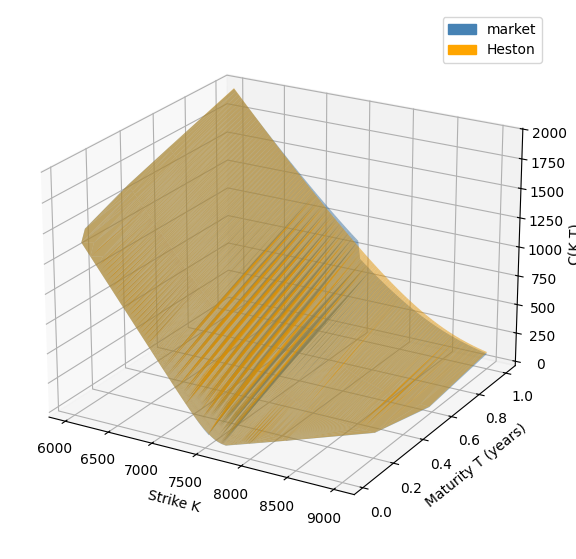

In [13]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(K, T, c_mkt,   color="steelblue", alpha=0.5, edgecolor="none")
ax.plot_trisurf(K, T, c_model, color="orange",    alpha=0.5, edgecolor="none")
ax.legend(handles=[Patch(color="steelblue", label="market"),
                     Patch(color="orange",    label="Heston")])
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("C(K,T)")
ax.view_init(elev=22, azim=-60)
plt.show()

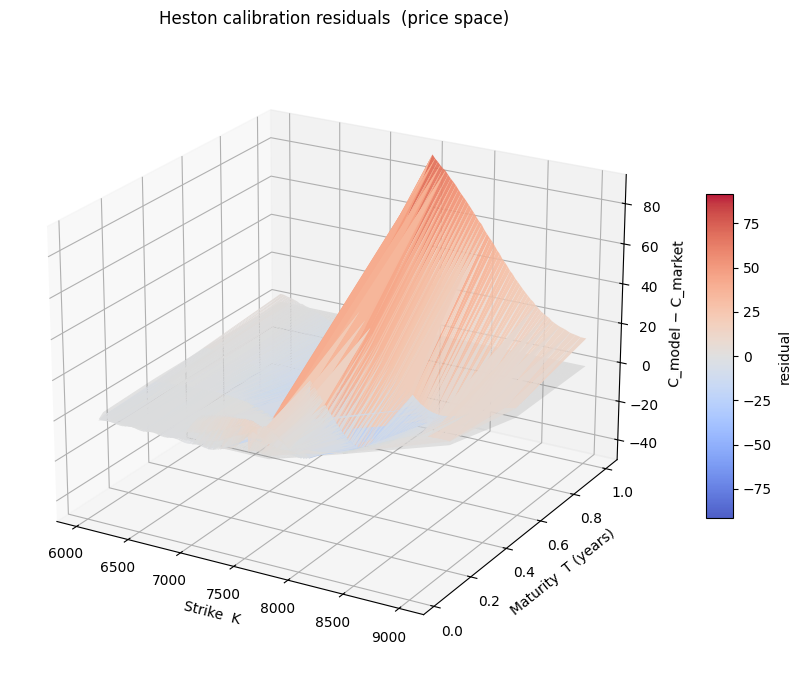

In [14]:
import numpy as np
from matplotlib import cm

# same aligned arrays from the filtered calls frame
K = calls["strike"].to_numpy(float)
T = calls["ttm"].to_numpy(float)
c_mkt = calls["mid"].to_numpy(float)
c_model = model.call(K, s0, r, T)          # calibrated model.params
resid = c_model - c_mkt                    # the error we want to see

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# symmetric color scale centered at 0 so blue=under, red=over, white=perfect
vmax = np.abs(resid).max()
surf = ax.plot_trisurf(K, T, resid, cmap=cm.coolwarm,
                       vmin=-vmax, vmax=vmax, edgecolor="none", alpha=0.9)

# flat reference plane at zero error
ax.plot_trisurf(K, T, np.zeros_like(resid), color="gray", alpha=0.15, edgecolor="none")

ax.set_xlabel("Strike  K")
ax.set_ylabel("Maturity  T (years)")
ax.set_zlabel("C_model − C_market")
ax.set_title("Heston calibration residuals  (price space)")
fig.colorbar(surf, shrink=0.5, aspect=12, label="residual")
ax.view_init(elev=22, azim=-60)
fig.tight_layout()
plt.show()